# Week 4-1 · MMT-02 — Execution Strategy II (where & how to place the order)
**Practice notebook — the lecture's own Excel examples, reproduced in Python.**

MMT-01 taught the *order types*. This lecture answers the desk's real question: a client says
*"buy 30,000 Microsoft shares by 3pm at the best price"* — **where** do you place each slice, at **what
price**, in **what quantity**, and how do you avoid being **manipulated**?

We use the exact numbers from the lecture's `MMT_02_code_Inclass file.xlsm`:
- `microsoft_intraday.csv` — the Microsoft VWAP demo (→ day VWAP **927.47**)
- the **expected-value** table (probability of fill × gain per level → best level is **2**, not 1)
- the **pegging + discretion** blend cascade, and the **guerrilla/spoofing** trap

**What we reproduce (all numbers verified against the lecture sheet):**
1. **VWAP** benchmark — was buying at 925 a good fill?
2. **Expected value** of order placement: prob-of-fill × gain across 5 levels
3. **Discretion** order EV (no-discretion 0.125 vs discretion 0.15)
4. **Pegging + discretion** blend — the price cascade, and the *fair-price guard*
5. **Guerrilla (spoofing)** simulation — how baiting works and why the guard defends you
6. **Time horizon** (TTH) — can the order even finish in time?


In [1]:
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
pd.set_option("display.width",120); pd.set_option("display.max_columns",20)
print("pandas", pd.__version__)


pandas 3.0.3


## Part 1 — VWAP: the benchmark that grades your execution

The client will judge you against **VWAP** (volume-weighted average price). If you buy *below* the
day's VWAP you did well; *above* it, you overpaid. VWAP weights each interval's price by its volume:
$$ \text{VWAP} = \frac{\sum (\text{price}\times\text{volume})}{\sum \text{volume}} $$
Here is the lecture's Microsoft session (21 fifteen-minute marks).

In [2]:
mkt = pd.read_csv("microsoft_intraday.csv")
mkt["px_x_vol"] = mkt["AvgTradePrice"] * mkt["TotalQtyTraded"]
mkt["running_vwap"] = mkt["px_x_vol"].cumsum() / mkt["TotalQtyTraded"].cumsum()
day_vwap = mkt["px_x_vol"].sum() / mkt["TotalQtyTraded"].sum()
print(mkt[["Time","AvgTradePrice","TotalQtyTraded","running_vwap"]].head(6).to_string(index=False))
print("...")
print(f"\nSTEP TABLE — day VWAP")
print(f"  sum(price x volume) = {mkt['px_x_vol'].sum():,.0f}")
print(f"  sum(volume)         = {mkt['TotalQtyTraded'].sum():,.0f}")
print(f"  VWAP = sum/sum      = {day_vwap:.2f}")
bought = 925.0
print(f"\n  You bought 30,000 @ avg {bought:.2f}  vs day VWAP {day_vwap:.2f}")
print(f"  -> {bought-day_vwap:+.2f} per share = {'GOOD (below VWAP)' if bought<day_vwap else 'BAD (above VWAP)'}")


    Time  AvgTradePrice  TotalQtyTraded  running_vwap
10:00:00         920.65            5000    920.650000
10:15:00         920.95           15000    920.875000
10:30:00         921.75            7500    921.113636
10:45:00         920.50           10000    920.950000
11:00:00         923.15           50000    922.207143
11:15:00         924.05          150000    923.371053
...

STEP TABLE — day VWAP
  sum(price x volume) = 28,639,943,075
  sum(volume)         = 30,879,500
  VWAP = sum/sum      = 927.47

  You bought 30,000 @ avg 925.00  vs day VWAP 927.47
  -> -2.47 per share = GOOD (below VWAP)


### Validation bridge 1

This code cell continues the calculation from the previous cell. The bridge is added in the validated copy so every code cell has a markdown explanation immediately before it.

In [3]:
fig, ax = plt.subplots(figsize=(8.4,3.3))
x = range(len(mkt))
ax.plot(x, mkt["AvgTradePrice"], color="#94a3b8", lw=1, marker="o", ms=2, label="avg trade price")
ax.plot(x, mkt["running_vwap"], color="#2563eb", lw=2, label="running VWAP")
ax.axhline(day_vwap, color="#16a34a", ls="--", lw=1.2, label=f"day VWAP {day_vwap:.2f}")
ax.axhline(925, color="#dc2626", ls=":", lw=1.2, label="your fill 925")
ax.set_xticks(list(x)[::3]); ax.set_xticklabels(mkt["Time"][::3], rotation=45, fontsize=7)
ax.set_ylabel("price"); ax.set_title("Microsoft session — fill vs VWAP"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("chart_1_vwap.png", dpi=110); plt.show()
print("Your 925 (red) sits below both the running and day VWAP -> a good execution.")
print("saved chart_1_vwap.png")


Your 925 (red) sits below both the running and day VWAP -> a good execution.
saved chart_1_vwap.png


C:\Users\hsaeed\AppData\Local\Temp\1\ipykernel_24092\1050607141.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig("chart_1_vwap.png", dpi=110); plt.show()


## Part 2 — *Where* to place: expected value across order-book levels

VWAP tells you the *fair price*; now **how aggressive** should the limit order be? Place it closer to
the touch and the **probability of a fill** is high but the **gain** (fair − your price) is small.
Place it deeper and the gain is big but fills are rare. The right tool is **expected value**:
$$ EV = P(\text{fill}) \times \text{gain} $$
These are the lecture's exact numbers — note the winner is **level 2**, not level 1.

In [4]:
ev = pd.DataFrame({
    "level":      [1, 2, 3, 4, 5],
    "gain":       [0.25, 0.75, 1.25, 2.00, 2.25],          # fair price - placement price
    "prob_fill":  [0.51111, 0.25037, 0.11422, 0.067189, 0.057111],
})
ev["EV"] = ev["gain"] * ev["prob_fill"]
best = ev.loc[ev["EV"].idxmax()]
print("STEP TABLE — expected value per level (EV = gain x prob)")
print(ev.to_string(index=False, float_format=lambda v: f"{v:.5f}"))
print(f"\n  BEST placement = level {int(best.level)}  (EV = {best.EV:.5f})")
print("  Level 1 fills most often but pays least; level 2 maximises EV. "
      "Closest is NOT optimal.")


STEP TABLE — expected value per level (EV = gain x prob)
 level    gain  prob_fill      EV
     1 0.25000    0.51111 0.12778
     2 0.75000    0.25037 0.18778
     3 1.25000    0.11422 0.14278
     4 2.00000    0.06719 0.13438
     5 2.25000    0.05711 0.12850

  BEST placement = level 2  (EV = 0.18778)
  Level 1 fills most often but pays least; level 2 maximises EV. Closest is NOT optimal.


### Validation bridge 2

This code cell continues the calculation from the previous cell. The bridge is added in the validated copy so every code cell has a markdown explanation immediately before it.

In [5]:
fig, ax = plt.subplots(figsize=(7.4,3.2))
bars = ax.bar(ev["level"], ev["EV"], color=["#93c5fd"]*5)
bars[int(best.level)-1].set_color("#f59e0b")
ax.set_xlabel("order-book level"); ax.set_ylabel("expected value")
ax.set_title("Expected value of placement — peak at level 2")
for _, r in ev.iterrows():
    ax.text(r.level, r.EV+0.002, f"{r.EV:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("chart_2_ev.png", dpi=110); plt.show()
print("saved chart_2_ev.png")


saved chart_2_ev.png


C:\Users\hsaeed\AppData\Local\Temp\1\ipykernel_24092\2520531774.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig("chart_2_ev.png", dpi=110); plt.show()


## Part 3 — Discretion orders: trade aggressively *only when it pays*

A **discretion order** is a limit order with a hidden, more-aggressive second price it will pay *if*
a matching order appears. The lecture compares two cases at fair price **100.25**:

In [6]:
fair = 100.25
# Case 1: passive limit at best bid 100, 50% fill chance
ev1 = 0.5 * (fair - 100.00)
# Case 2: discretion lets it lift to 100.10 with certainty when an ask appears
ev2 = 1.0 * (fair - 100.10)
print("STEP TABLE — discretion expected value (fair = 100.25)")
print(f"  Case 1 (no discretion): EV = 0.50 x (100.25 - 100.00) = {ev1:.3f}")
print(f"  Case 2 (discretion 10c): EV = 1.00 x (100.25 - 100.10) = {ev2:.3f}")
print(f"  -> discretion wins: {ev2:.3f} > {ev1:.3f}  (a sure smaller edge beats a coin-flip bigger one)")


STEP TABLE — discretion expected value (fair = 100.25)
  Case 1 (no discretion): EV = 0.50 x (100.25 - 100.00) = 0.125
  Case 2 (discretion 10c): EV = 1.00 x (100.25 - 100.10) = 0.150
  -> discretion wins: 0.150 > 0.125  (a sure smaller edge beats a coin-flip bigger one)


## Part 4 — Blending pegging + discretion (and the guard that saves you)

**Pegging** keeps your buy at *best bid + 1 tick* automatically. Add a **discretion range** and the
two can *cascade*: a competitor nudges the bid → your peg jumps → that brings the ask inside your
discretion range → you fire and lift the offer. Powerful, but it can make you pay too much — so the
**last check before every order must be: buy price ≤ fair price.**

We simulate the lecture's exact case: peg at *best bid + 10c*, discretion *20c*, a new buy arrives at
100.2.

In [7]:
def blended_buy(best_bid, best_ask, peg_offset, disc_range, fair_price):
    log = []
    my_price = round(best_bid + peg_offset, 2)         # pegging
    log.append((f"peg at best_bid {best_bid} + {peg_offset}", my_price))
    # discretion: willing to lift up to my_price + disc_range if an ask sits there
    reach = round(my_price + disc_range, 2)
    if best_ask <= reach:
        proposed = best_ask
        log.append((f"ask {best_ask} within discretion (reach {reach}) -> propose lift", proposed))
        # THE GUARD
        if proposed <= fair_price:
            log.append(("guard: price <= fair -> EXECUTE", proposed))
            filled = proposed
        else:
            log.append((f"guard: {proposed} > fair {fair_price} -> BLOCKED, stay passive", my_price))
            filled = None
    else:
        log.append(("no ask in discretion range -> rest passive", my_price))
        filled = None
    return log, filled

# Scenario A — fair price 100.55: the lift to 100.5 is at/below fair, so it EXECUTES
log, filled = blended_buy(best_bid=100.2, best_ask=100.5, peg_offset=0.10,
                          disc_range=0.20, fair_price=100.55)
print("Scenario A — cascade with fair price 100.55:")
for step, px in log:
    print(f"  {step:<52} -> {px}")
print(f"  result: {'FILLED @ '+str(filled)+' (<= fair, good trade)' if filled else 'no fill'}")

# Scenario B — same cascade but fair price 100.45: the lift to 100.5 is ABOVE fair -> BLOCKED
log2, filled2 = blended_buy(100.2, 100.5, 0.10, 0.20, fair_price=100.45)
print("\nScenario B — same cascade but fair price only 100.45:")
for step, px in log2:
    print(f"  {step:<52} -> {px}")
print(f"  result: {'filled @ '+str(filled2) if filled2 else 'BLOCKED by guard (would overpay vs fair) -> stay passive'}")


Scenario A — cascade with fair price 100.55:
  peg at best_bid 100.2 + 0.1                          -> 100.3
  ask 100.5 within discretion (reach 100.5) -> propose lift -> 100.5
  guard: price <= fair -> EXECUTE                      -> 100.5
  result: FILLED @ 100.5 (<= fair, good trade)

Scenario B — same cascade but fair price only 100.45:
  peg at best_bid 100.2 + 0.1                          -> 100.3
  ask 100.5 within discretion (reach 100.5) -> propose lift -> 100.5
  guard: 100.5 > fair 100.45 -> BLOCKED, stay passive  -> 100.3
  result: BLOCKED by guard (would overpay vs fair) -> stay passive


## Part 5 — Guerrilla bots & spoofing — and why the guard matters

A **guerrilla / spoofing** algo *baits* a naive pegger. It posts a tiny order far above the bid; the
pegger (with no guard) chases it up; the bot then sells into the inflated price and buys back low,
pocketing the difference. (Navinder Sarao did exactly this — and went to jail.) We replay the
lecture's sequence and price the manipulator's profit.

In [8]:
fair = 100.5
# the bait sequence from the sheet: bot posts tiny bids, naive pegger (peg = best_bid + 5c) chases
naive_peg_offset = 0.05
bait_bids = [100.2, 100.8]        # bot's tiny bait bids
my_price = 100.05
print("Naive pegger has NO fair-price guard, pegs at best_bid + 5c:")
for b in bait_bids:
    my_price = round(b + naive_peg_offset, 2)
    print(f"  bot baits best_bid -> {b};  you chase to {my_price}")
sell_to_you = my_price            # bot sells to you here (100.85)
buyback = 100.5                   # market snaps back, bot buys to cover
profit = (sell_to_you - buyback) * 1000
print(f"\n  bot SELLS 1000 to you at {sell_to_you}, market snaps back, bot BUYS back at {buyback}")
print(f"  manipulator profit = ({sell_to_you} - {buyback}) x 1000 = ${profit:,.0f}")
print(f"  YOU overpaid {sell_to_you-fair:.2f}/share vs fair {fair} = ${(sell_to_you-fair)*1000:,.0f} loss")

print("\nWith the GUARD (never bid above fair 100.5): you would refuse every chase above 100.5,")
print("the bait fails, and the bot earns nothing from you.")


Naive pegger has NO fair-price guard, pegs at best_bid + 5c:


  bot baits best_bid -> 100.2;  you chase to 100.25
  bot baits best_bid -> 100.8;  you chase to 100.85

  bot SELLS 1000 to you at 100.85, market snaps back, bot BUYS back at 100.5
  manipulator profit = (100.85 - 100.5) x 1000 = $350
  YOU overpaid 0.35/share vs fair 100.5 = $350 loss

With the GUARD (never bid above fair 100.5): you would refuse every chase above 100.5,
the bait fails, and the bot earns nothing from you.


## Part 6 — Can the order even finish? Time horizon (TTH)

Slicing only works if the market has enough volume. The lecture's rule for AXISBANK (buy 10,000,
high urgency, algo efficiency 15%, 500 shares/min trade):
$$ \text{TTH} = \frac{\text{order shares}}{\text{vol ratio} \times \text{min vol}} $$

In [9]:
order_shares, vol_ratio, min_vol = 10000, 0.15, 500
per_min = vol_ratio * min_vol
tth = order_shares / per_min
print("STEP LADDER — theoretical time horizon")
print(f"  market trades                  = {min_vol} shares/min")
print(f"  my algo captures vol_ratio     = {vol_ratio} (high urgency)")
print(f"  -> I trade {vol_ratio}x{min_vol}        = {per_min:.0f} shares/min")
print(f"  TTH = {order_shares} / {per_min:.0f}        = {tth:.2f} minutes")
print(f"  check: {tth:.2f} min x {per_min:.0f}/min  = {tth*per_min:,.0f} shares  (= the order)")


STEP LADDER — theoretical time horizon
  market trades                  = 500 shares/min
  my algo captures vol_ratio     = 0.15 (high urgency)
  -> I trade 0.15x500        = 75 shares/min
  TTH = 10000 / 75        = 133.33 minutes
  check: 133.33 min x 75/min  = 10,000 shares  (= the order)


## Summary — what to remember
- **VWAP** grades execution: buy below it = good. (Microsoft day VWAP **927.47**, fill 925 = good.)
- Place orders by **expected value** = P(fill) × gain — the closest level is **not** the best (level 2 wins).
- **Discretion** takes a sure small edge over a coin-flip big one (0.15 > 0.125).
- **Pegging + discretion** can cascade you into overpaying → the **fair-price guard** (buy ≤ fair) is mandatory.
- **Spoofing** baits naive peggers; the same guard plus size/spike checks defends you (and it's illegal).
- **TTH** checks the order can finish in time given the algo's share of market volume.


---

# Official resource addendum

The following additive section incorporates the official MMT-02 notes, FAQ, and in-class workbook logic that are not fully explicit in the original practice notebook.

## Setup

Load the lecture's Microsoft intraday data plus the addendum rule tables generated from the official resources.

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
root = Path(".")
mkt = pd.read_csv(root / "microsoft_intraday.csv")
order_spec = pd.read_csv(root / "mmt02_order_specifications.csv")
rules = pd.read_csv(root / "mmt02_execution_rules.csv")
schedule = pd.read_csv(root / "mmt02_volume_schedule.csv")
print(f"loaded {len(mkt)} market rows, {len(order_spec)} order fields, {len(rules)} execution rules")

loaded 21 market rows, 8 order fields, 12 execution rules


## 1. Intake checklist before the algo starts

The official notes do not begin with pegging. They begin with the order ticket: symbol, side, size, limit, urgency, horizon, instructions, and supporting market data. Those fields decide whether the order belongs in automation at all.

In [11]:
order_spec

,field,official_resource_detail,execution_use
0,Trading symbol,"Security to execute, for example MSFT or AXISBANK",Routes the order to the correct instrument and...
1,Side,Buy or sell,Determines same-side and opposite-side book ch...
2,Size,Parent quantity plus any minimum or maximum ch...,"Controls reserve, slice size, stub handling, a..."
3,Price limit,Optional client maximum buy price or minimum s...,Hard guard before any peg or discretion order ...
4,Urgency,"Low, medium, high, or an explicit deadline",Selects participation rate and discretion aggr...
5,Time horizon,Deadline or remaining trading window,Compared with theoretical time horizon before ...
6,Special instructions,"Examples: avoid marketable orders, use post-on...",Overrides the default automated logic when needed
7,Supporting market data,"21-day ADV, historical spread, depth, and volu...","Feeds the VWAP schedule, significant-size chec..."


## 2. Automated VWAP is a scheduling problem, not only a benchmark

A VWAP algo filters unsuitable orders, predicts the intraday volume curve, trades more during heavy-volume intervals, and reduces impact in thin intervals. The 30,000-share parent order below is allocated in proportion to the observed Microsoft volume curve.

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(schedule))
ax1.bar(x, schedule["TotalQtyTraded"] / 1_000_000, color="#0f766e", alpha=0.82, label="market volume (millions)")
ax1.set_ylabel("Market volume (millions)")
ax1.set_xticks(x)
ax1.set_xticklabels(schedule["Time"].str.slice(0, 5), rotation=45, ha="right")
ax1.grid(axis="y", alpha=0.22)
ax2 = ax1.twinx()
ax2.plot(x, schedule["target_slice_shares"], color="#b45309", marker="o", lw=2.2, label="target child shares")
ax2.set_ylabel("Target child shares")
fig.suptitle("Volume-weighted schedule for a 30,000-share parent order", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("chart_addendum_1_mmt02_volume_schedule.png", dpi=140, bbox_inches="tight")
plt.show()

schedule[["Time", "TotalQtyTraded", "volume_share", "target_slice_shares", "cum_target_shares", "running_vwap", "aggression_cue"]].head(10)

C:\Users\hsaeed\AppData\Local\Temp\1\ipykernel_24092\3272218466.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,Time,TotalQtyTraded,volume_share,target_slice_shares,cum_target_shares,running_vwap,aggression_cue
0,10:00:00,5000,0.000162,4,4,920.650000,patient: price at/below running VWAP
1,10:15:00,15000,0.000486,14,18,920.875000,watch: price above running VWAP
2,10:30:00,7500,0.000243,7,25,921.113636,watch: price above running VWAP
3,10:45:00,10000,0.000324,9,34,920.950000,patient: price at/below running VWAP
4,11:00:00,50000,0.001619,48,82,922.207143,watch: price above running VWAP
5,11:15:00,150000,0.004858,145,227,923.371053,watch: price above running VWAP
6,11:30:00,5000,0.000162,4,231,923.391237,watch: price above running VWAP
7,11:45:00,125000,0.004048,121,352,923.989456,watch: price above running VWAP
8,12:00:00,10000,0.000324,9,361,923.973841,patient: price at/below running VWAP
9,12:15:00,17000,0.000551,16,377,923.990051,watch: price above running VWAP


## 3. Theoretical and practical time horizon gate

The resource formula is `TTH = order shares / (vol_ratio * min_vol)`. Practical horizon is the lesser of the remaining time and TTH. If TTH divided by practical horizon is greater than 2, the notes treat time as insufficient for normal automated completion.

In [13]:
def time_horizon_check(order_shares, urgency, min_vol, time_remaining_min):
    vol_ratio_by_urgency = {"high": 0.15, "medium": 0.075, "low": 0.025}
    vol_ratio = vol_ratio_by_urgency[urgency]
    tth = order_shares / (vol_ratio * min_vol)
    pth = min(time_remaining_min, tth)
    return {
        "order_shares": order_shares,
        "urgency": urgency,
        "vol_ratio": vol_ratio,
        "min_vol": min_vol,
        "tth_min": round(tth, 2),
        "practical_horizon_min": round(pth, 2),
        "tth_over_pth": round(tth / pth, 2),
        "status": "manual review / more aggressive logic" if tth / pth > 2 else "fits automated horizon",
    }

pd.DataFrame([
    time_horizon_check(10000, "high", 500, 120),
    time_horizon_check(10000, "medium", 500, 120),
    time_horizon_check(10000, "low", 500, 120),
])

,order_shares,urgency,vol_ratio,min_vol,tth_min,practical_horizon_min,tth_over_pth,status
0,10000,high,0.150,500,133.33,120,1.11,fits automated horizon
1,10000,medium,0.075,500,266.67,120,2.22,manual review / more aggressive logic
2,10000,low,0.025,500,800.00,120,6.67,manual review / more aggressive logic


## 4. Peg-loop and significant-size checks

The peg should not blindly chase every quote change. The official flow adds an alone flag, threshold tests, and a significant-size rule: significant size is the larger of 500 shares or 50 percent of current bid size.

In [14]:
def significant_size_ahead(bid_size, open_peg_at_bid, peg_target, order_price, bid):
    sig_size = max(500, 0.50 * bid_size)
    size_ahead = bid_size - open_peg_at_bid
    should_adjust = (peg_target > order_price) and (peg_target >= bid) and (size_ahead >= sig_size)
    return {
        "bid_size": bid_size,
        "open_peg_at_bid": open_peg_at_bid,
        "size_ahead": size_ahead,
        "sig_size": sig_size,
        "peg_target": peg_target,
        "order_price": order_price,
        "bid": bid,
        "adjust_peg_price": should_adjust,
    }

pd.DataFrame([
    significant_size_ahead(1200, 100, 100.05, 100.00, 100.00),
    significant_size_ahead(700, 400, 100.05, 100.00, 100.00),
    significant_size_ahead(400, 0, 100.05, 100.00, 100.00),
])

,bid_size,open_peg_at_bid,size_ahead,sig_size,peg_target,order_price,bid,adjust_peg_price
0,1200,100,1100,600.0,100.05,100.0,100.0,True
1,700,400,300,500.0,100.05,100.0,100.0,False
2,400,0,400,500.0,100.05,100.0,100.0,False


## 5. Dynamic discretion range

Static discretion is cumbersome because urgency, trend, spread, and available opposite-side liquidity change. The official formula frames the discretion range as a function of base range, expected spread, trend, and liquidity. The example below caps negative ranges at zero.

In [15]:
expected_spread = 0.50
base_dr = 0.30 * expected_spread
dr = pd.read_csv(root / "mmt02_dynamic_discretion_scenarios.csv")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = ["#64748b", "#0f766e", "#1d4ed8", "#b45309"]
ax.barh(dr["scenario"], dr["dynamic_dr"], color=colors)
ax.axvline(base_dr, color="#111827", lw=1.3, ls="--", label=f"base DR = {base_dr:.2f}")
for i, v in enumerate(dr["dynamic_dr"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("Discretion range in price units")
ax.set_title("Dynamic discretion range scenarios", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.savefig("chart_addendum_2_mmt02_dynamic_discretion.png", dpi=140, bbox_inches="tight")
plt.show()

dr

C:\Users\hsaeed\AppData\Local\Temp\1\ipykernel_24092\559034835.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,scenario,trend,liq,expected_spread,base_dr,dynamic_dr
0,"negative trend, no liquidity",-1,0,0.5,0.15,0.00
1,"flat trend, no liquidity",0,0,0.5,0.15,0.15
2,"positive trend, no liquidity",1,0,0.5,0.15,0.65
3,positive trend plus liquidity,1,1,0.5,0.15,1.15


## 6. Resource rules and operational controls

These are the rules that convert the lecture ideas into an execution process: filter before accepting the order, schedule by volume, guard peg adjustments, keep discretion dynamic, and maintain compliance controls.

In [16]:
rules

,rule,trigger,action,risk_control
0,incoming_order_filter,Order is illiquid or very large relative to ADV,Divert for manual attention,Avoid forcing an automated strategy into bad l...
1,volume_distribution,Projected intraday volume is high,Allocate a larger slice,Use liquidity when the market can absorb the o...
2,thin_period_control,Projected volume is thin,Reduce participation and prefer passive posting,Limit market impact and information leakage
3,tth_gate,TTH / practical horizon greater than 2,Flag time as insufficient,Escalate before the strategy runs out of time
4,peg_loop_guard,Peg target moves but the order is alone or bei...,"Wait, correct down, or cancel according to thr...",Avoid chasing artificial quote moves
5,significant_size_check,"Size ahead at bid is at least max(500 shares, ...",Allow peg-price adjustment despite normal thre...,React when meaningful queue depth changes exec...
6,discretion_price,Adjusted spread is within the discretion range...,Send an aggressive discretion child order,Take liquidity only when the hidden second pri...
7,dynamic_dr,"Trend, opposite-side liquidity, urgency, and e...",Update discretion range instead of using a sta...,Keep the order on schedule without blindly ove...
8,iceberg_awareness,Opposite liquidity refills repeatedly,Treat visible size as incomplete information,Avoid assuming the displayed book is the full ...
9,ioc_order,Need immediate execution only,Fill what is available now and cancel the rest,Prevents stale resting exposure


## 7. Flow view

The flow chart below is a compact view of the official logic: intake, fit gate, VWAP schedule, passive peg agent, book guards, discretion agent, and final controls.

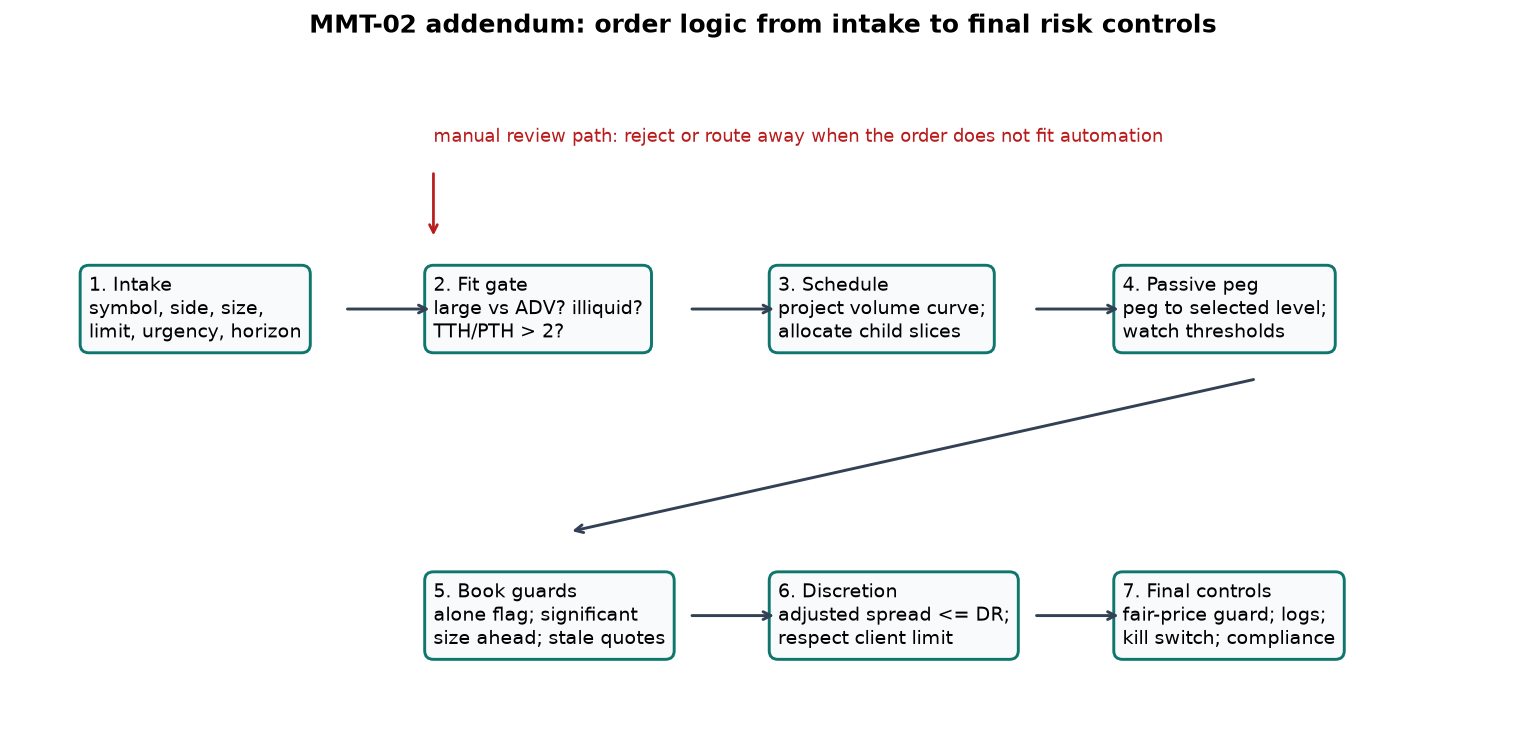

In [17]:
from IPython.display import Image, display
display(Image(filename="chart_addendum_3_mmt02_order_logic_flow.png"))

## Addendum summary

The original practice notebook explains the core trading intuition. This addendum adds the production checks from the resources: order intake, manual-review gates, volume scheduling, theoretical/practical horizon checks, significant-size logic, dynamic discretion, IOC/iceberg/TBT clarifications, and compliance safeguards.